# Cycle-history exploration

This committed demonstration uses only a long, independently invented synthetic history. Private analysis uses the exact same validation, dataset-construction, statistics, and plotting code by changing `CYCLE_FORECAST_DATA_PATH` locally. Actual private statistics, fingerprints, figures, and notebook output must never be committed.

In [1]:
import os

# Keep the committed notebook on independently invented synthetic data.
# Set the private raw path only in a local session, and never commit its output.
# os.environ["CYCLE_FORECAST_DATA_PATH"] = "data/raw/cycle_history.csv"
os.environ["CYCLE_FORECAST_DATA_PATH"] = "data/synthetic/sample_cycle_history.csv"

In [2]:
from pathlib import Path

import cycle_forecast
from cycle_forecast.analysis import explore_cycle_history, plot_cycle_history
from cycle_forecast.data import build_cycle_dataset, load_cycle_history

## Load and construct the dataset

Validation and target construction use the same package functions as future training and evaluation code.

In [3]:
project_root = Path(cycle_forecast.__file__).resolve().parents[2]
configured_path = Path(
    os.environ.get(
        "CYCLE_FORECAST_DATA_PATH", "data/synthetic/sample_cycle_history.csv"
    )
)
data_path = (
    configured_path if configured_path.is_absolute() else project_root / configured_path
)
records = load_cycle_history(path=data_path)
dataset = build_cycle_dataset(records=records)
print(f"Completed cycles: {len(dataset.rows)}")
print(f"Dataset fingerprint: {dataset.fingerprint}")

Completed cycles: 120
Dataset fingerprint: sha256:80e81294405e345e92380c69825d5d3a8dfb7999ec81b892537a176cc014aff9


## Numerical exploration

The immutable summary reports distribution, variability, chronological trend, and lag-1 autocorrelation. Any committed result from this notebook must come only from the synthetic fixture.

In [4]:
exploration = explore_cycle_history(dataset=dataset)
exploration

CycleHistoryExploration(dataset_fingerprint='sha256:80e81294405e345e92380c69825d5d3a8dfb7999ec81b892537a176cc014aff9', cycle_count=120, cycle_length_frequencies=(CycleLengthFrequency(cycle_length_days=25, count=4), CycleLengthFrequency(cycle_length_days=26, count=7), CycleLengthFrequency(cycle_length_days=27, count=7), CycleLengthFrequency(cycle_length_days=28, count=10), CycleLengthFrequency(cycle_length_days=29, count=17), CycleLengthFrequency(cycle_length_days=30, count=17), CycleLengthFrequency(cycle_length_days=31, count=12), CycleLengthFrequency(cycle_length_days=32, count=11), CycleLengthFrequency(cycle_length_days=33, count=11), CycleLengthFrequency(cycle_length_days=34, count=9), CycleLengthFrequency(cycle_length_days=35, count=7), CycleLengthFrequency(cycle_length_days=36, count=4), CycleLengthFrequency(cycle_length_days=37, count=1), CycleLengthFrequency(cycle_length_days=38, count=3)), mean_days=30.725, median_days=30.0, minimum_days=25, maximum_days=38, standard_deviation_

## Visual exploration

The three panels show whole-day frequencies, chronological observations with median, fitted trend, and trailing mean, and adjacent-cycle relationships. The committed demonstration is synthetic; figures produced from the private path stay local even though they use this identical plotting function.

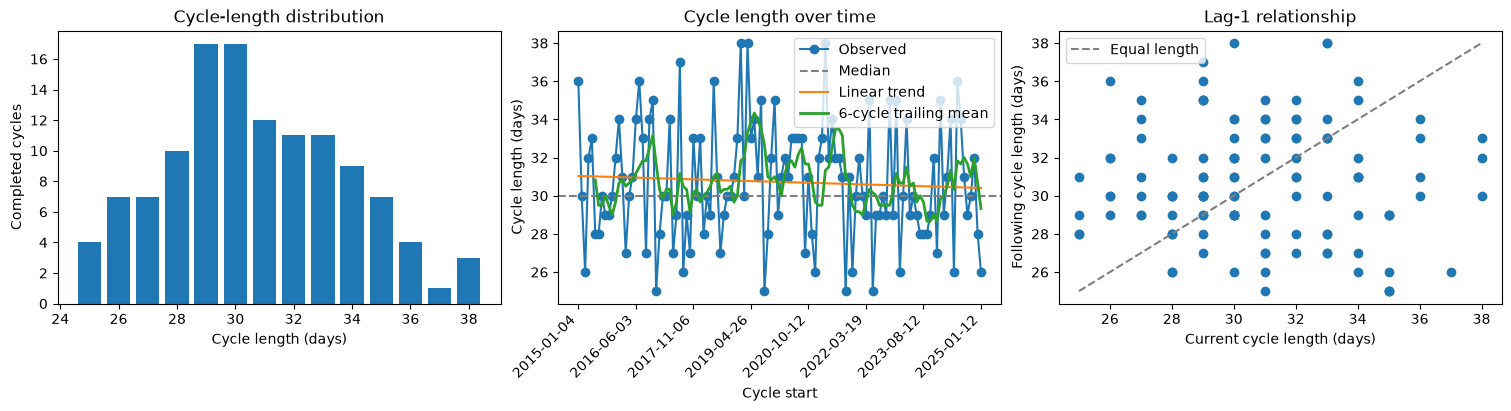

In [5]:
figure = plot_cycle_history(dataset=dataset, exploration=exploration)

## Interpretation guardrails

These statistics and plots are descriptive. They do not establish causality, medical meaning, or future predictability. Predictive value must be assessed later with leakage-safe walk-forward evaluation.